<a href="https://colab.research.google.com/github/dalibug/ML-Captcha-Model/blob/main/captcha_training_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAPTCHA Recognition Training on Google Colab

This notebook trains a CAPTCHA recognition model using either:
- **Segmentation-based CNN**: Segments characters then classifies each
- **CRNN**: End-to-end sequence recognition without segmentation

## Setup Instructions:
1. Upload your entire project folder to Google Drive
2. Update `DRIVE_FOLDER_NAME` below to match your folder name
3. Run all cells sequentially
4. Choose model type: `'segmentation'` or `'crnn'` in the training cell


# 2. Environment Setup
## 2.1 Mount Google Drive

In [ ]:
# Mount Google Drive and set up paths
from google.colab import drive
import os
import shutil

# Unmount drive if already mounted
try:
    drive.flush_and_unmount()
except:
    pass

# Clear the mountpoint directory if it has leftover files
mountpoint = '/content/drive'
if os.path.exists(mountpoint):
    try:
        # Remove all contents of the directory
        for item in os.listdir(mountpoint):
            item_path = os.path.join(mountpoint, item)
            if os.path.isdir(item_path):
                shutil.rmtree(item_path)
            else:
                os.remove(item_path)
        print("✓ Cleared mountpoint directory")
    except Exception as e:
        print(f"Note: Could not clear mountpoint: {e}")

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# ============================================================================
# CONFIGURATION - UPDATE THIS TO MATCH YOUR FOLDER PATH
# ============================================================================
# Your folder is at: My Drive > Capitcha > ML-Captcha-Model
# So the path should be: "Capitcha/ML-Captcha-Model"
# If your folder is directly in My Drive, use just "ML-Captcha-Model"
DRIVE_FOLDER_PATH = "Capitcha/ML-Captcha-Model"  # UPDATE THIS if your path is different!

# Set base directory
BASE_DIR = f"/content/drive/MyDrive/{DRIVE_FOLDER_PATH}"

# Verify the folder exists
if not os.path.exists(BASE_DIR):
    print(f"ERROR: Folder '{BASE_DIR}' not found!")
    print(f"Please update DRIVE_FOLDER_PATH to match your folder path in Google Drive")
    print(f"\nCurrent path: My Drive/{DRIVE_FOLDER_PATH}")
    print(f"\nAvailable folders in MyDrive:")
    mydrive_path = "/content/drive/MyDrive"
    if os.path.exists(mydrive_path):
        for item in os.listdir(mydrive_path):
            item_path = os.path.join(mydrive_path, item)
            if os.path.isdir(item_path):
                print(f"  - {item}/")
                # Check if there's a subfolder
                try:
                    subitems = os.listdir(item_path)
                    for subitem in subitems[:5]:  # Show first 5 items
                        subitem_path = os.path.join(item_path, subitem)
                        if os.path.isdir(subitem_path):
                            print(f"    └─ {subitem}/")
                except:
                    pass
else:
    print(f"✓ Found project folder: {BASE_DIR}")

    # Change to project directory
    os.chdir(BASE_DIR)
    print(f"✓ Changed working directory to: {os.getcwd()}")

    # Check if samples folder exists
    samples_path = os.path.join(BASE_DIR, "samples")
    if os.path.exists(samples_path):
        num_files = sum([len(files) for r, d, files in os.walk(samples_path)])
        print(f"✓ Found 'samples' folder with {num_files} files")
    else:
        print(f"⚠ Warning: 'samples' folder not found at {samples_path}")


Mounted at /content/drive
✓ Found project folder: /content/drive/MyDrive/Capitcha/ML-Captcha-Model
✓ Changed working directory to: /content/drive/MyDrive/Capitcha/ML-Captcha-Model
✓ Found 'samples' folder with 8400 files


## 2.2 Install Required Packages

In [ ]:
# Install required packages (if not already installed)
%pip install -q torch torchvision opencv-python-headless tqdm matplotlib seaborn scikit-learn tensorboard


## 2.3 Import Libraries

In [ ]:
# ============================================================================
# Imports
# ============================================================================
import os
import random
import sys
import platform
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
from collections import Counter
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA Version: {torch.version.cuda}')


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
CUDA Version: 12.6


# 3. Data Configuration

In [ ]:
# ============================================================================
# Configuration
# ============================================================================

# Data directory (relative to BASE_DIR)
DATA_DIR = os.path.join(BASE_DIR, 'samples')
BATCH_SIZE = 64
EPOCHS = 10  # Simple approach needs fewer epochs
LEARNING_RATE = 0.001  # For Segmentation model
CRNN_LEARNING_RATE = 0.0001  # Lower LR for CRNN (10x smaller)
SAVE_DIR = os.path.join(BASE_DIR, 'checkpoints')
LOG_DIR = os.path.join(BASE_DIR, 'logs')

# Character and label mappings
# Include both uppercase and lowercase letters, plus digits
CHARS = '0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'
NUM_CHARS = len(CHARS)
CHAR_TO_IDX = {char: idx for idx, char in enumerate(CHARS)}
IDX_TO_CHAR = {idx: char for idx, char in enumerate(CHARS)}

# IMPORTANT: Set this to match your CAPTCHA length (4 or 5 characters)
SEQ_LENGTH = 4  # Updated to match dataset (4-character CAPTCHAs)

# Create directories
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  DATA_DIR: {DATA_DIR}")
print(f"  SEQ_LENGTH: {SEQ_LENGTH}")
print(f"  NUM_CHARS: {NUM_CHARS}")
print(f"  BATCH_SIZE: {BATCH_SIZE}")
print(f"  EPOCHS: {EPOCHS}")


Configuration:
  DATA_DIR: /content/drive/MyDrive/Capitcha/ML-Captcha-Model/samples
  SEQ_LENGTH: 4
  NUM_CHARS: 62
  BATCH_SIZE: 64
  EPOCHS: 10


# 4. Data Preprocessing
## 4.1 Character Segmentation Classes

## Segmentation Visualization

This cell visualizes how the **CharacterSegmenter** extracts individual characters from CAPTCHA images.

**What you'll see:**
- Original CAPTCHA image (full width)
- Each extracted character (segmented and resized to 32×32)
- Character labels from the filename

This helps verify that segmentation is working correctly before training!

##Segmented Character Dataset

In [ ]:
# ============================================================================
# Character Segmentation
# ============================================================================

class CharacterSegmenter:
    """

    Key technique from the Kaggle notebook:
    1. Find contours (connected components)
    2. Get bounding rectangles
    3. If < 4 chars found, split the widest box in half

    """

    def __init__(self, threshold=200):
        self.threshold = threshold

    def segment_chars(self, image_path, plot=False):
        """

        Key technique:
        1. Find contours
        2. Get bounding rectangles
        3. If < 4 chars, split widest box in half
        """
        # Load image
        img = cv2.imread(image_path)
        if img is None:
            pil_img = Image.open(image_path)
            img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

        # Convert to grayscale
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Binary threshold
        _, thresh = cv2.threshold(img_gray, self.threshold, 255, cv2.THRESH_BINARY)

        # Invert (characters = white, background = black)
        bit_not = cv2.bitwise_not(thresh)

        # Find contours
        contours, _ = cv2.findContours(bit_not, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        if len(contours) == 0:
            return []

        # Get bounding rectangles
        rects = [cv2.boundingRect(c) for c in contours]

        # Filter out very small contours (noise)
        rects = [r for r in rects if r[2] * r[3] > 20]

        # Sort by X coordinate (left to right)
        rects.sort(key=lambda x: x[0])

        # THE KEY TRICK: Split wide boxes if we have < SEQ_LENGTH characters
        while len(rects) < SEQ_LENGTH and len(rects) > 0:
            # Find widest rectangle
            rects.sort(key=lambda x: x[2])  # Sort by width
            wide_rect = rects.pop()  # Remove widest

            x, y, w, h = wide_rect
            # Split in two halves (simple but effective!)
            first_half = (x, y, w//2, h)
            second_half = (x + w//2, y, w - w//2, h)
            rects.append(first_half)
            rects.append(second_half)

            # Re-sort by X coordinate
            rects.sort(key=lambda x: x[0])

        # Take only expected number of characters
        rects.sort(key=lambda x: x[0])
        rects = rects[:SEQ_LENGTH]

        if len(rects) != SEQ_LENGTH:
            return []

        # Extract character images
        char_images = []
        padding = 2
        for x, y, w, h in rects:
            x1 = max(0, x - padding)
            y1 = max(0, y - padding)
            x2 = min(img_gray.shape[1], x + w + padding)
            y2 = min(img_gray.shape[0], y + h + padding)

            char_img = img_gray[y1:y2, x1:x2]
            # Resize to 32x32 for model input
            char_img = cv2.resize(char_img, (32, 32))
            char_images.append(char_img)

        return char_images

print("✓ CharacterSegmenter class defined")


✓ CharacterSegmenter class defined


##Preprocessing Helper Functions

Visualizing 5 CAPTCHA segmentation examples:


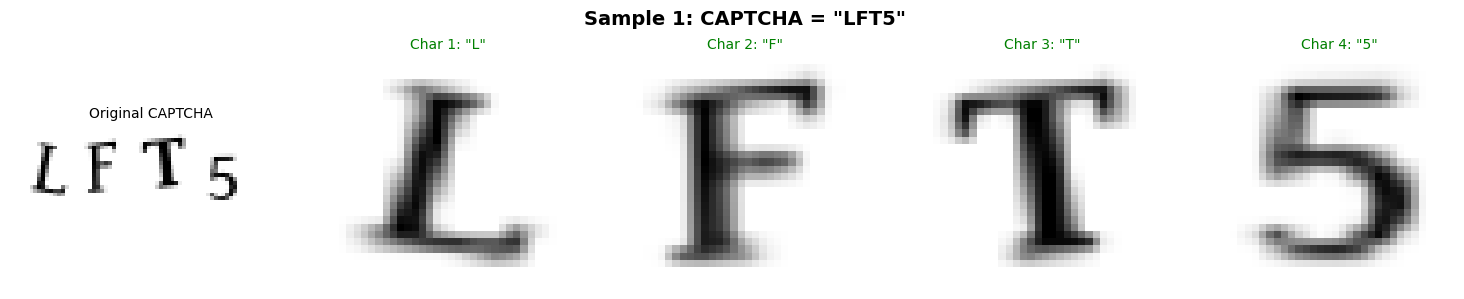

  ✓ Sample 1: 'LFT5' → Segmented into 4 characters


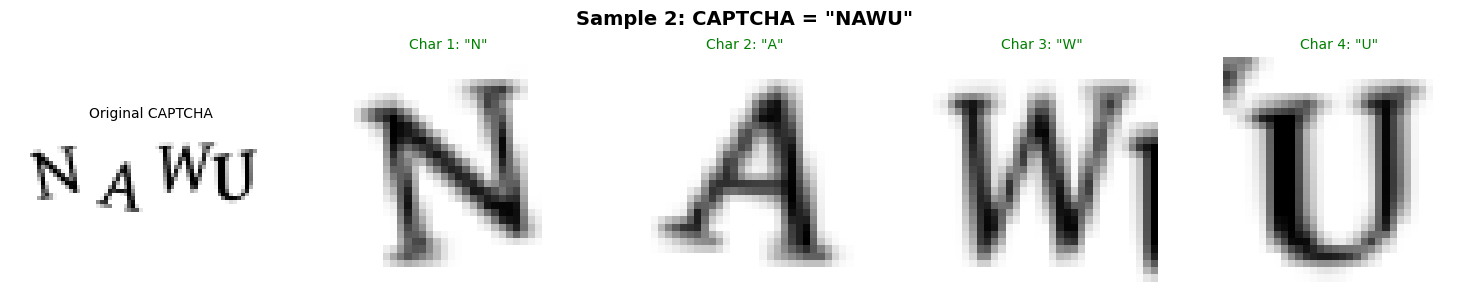

  ✓ Sample 2: 'NAWU' → Segmented into 4 characters


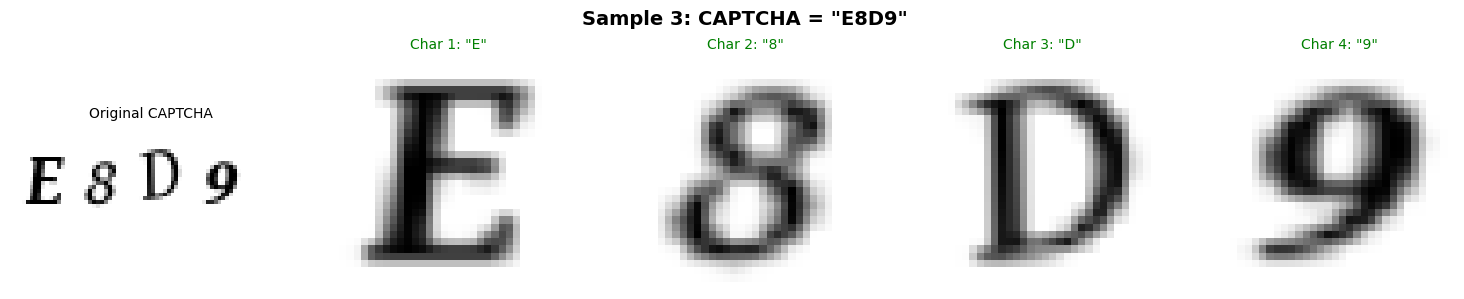

  ✓ Sample 3: 'E8D9' → Segmented into 4 characters


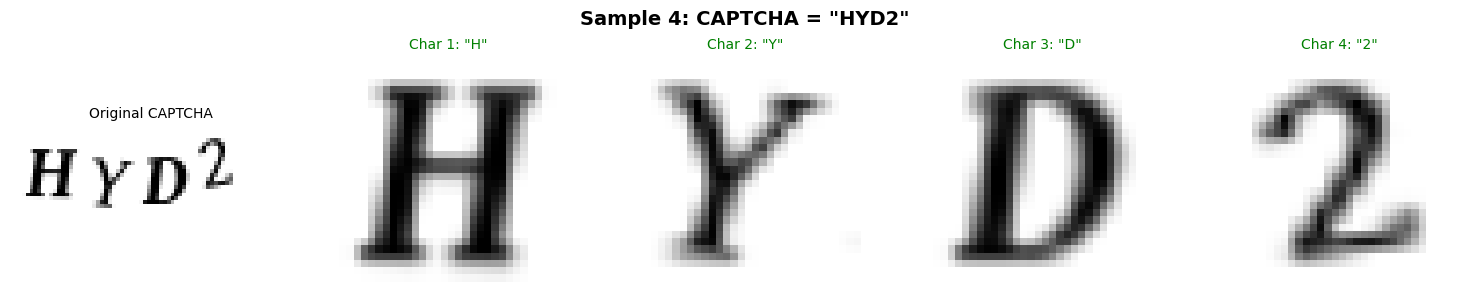

  ✓ Sample 4: 'HYD2' → Segmented into 4 characters


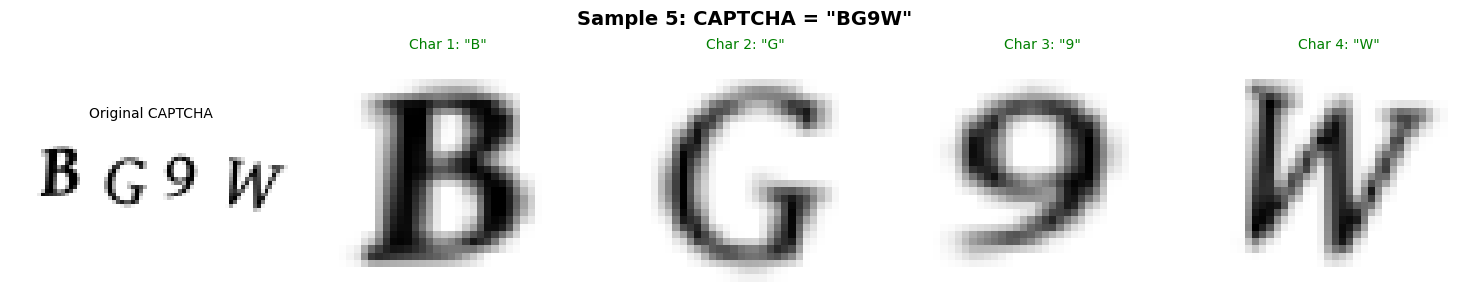

  ✓ Sample 5: 'BG9W' → Segmented into 4 characters
✓ Visualization complete!



In [ ]:
# ============================================================================
# VISUALIZE SEGMENTATION - Preview how characters are extracted
# ============================================================================

def visualize_segmentation_samples(data_dir, num_samples=3):
    """
    Visualize the segmentation process for sample CAPTCHA images.
    Shows original image and extracted characters side by side.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image
    import os
    import random

    # Find sample images
    image_files = []
    for root, dirs, files in os.walk(data_dir):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                rel_path = os.path.relpath(os.path.join(root, f), data_dir)
                filename = os.path.basename(rel_path)
                label = os.path.splitext(filename)[0]
                if len(label) == SEQ_LENGTH:
                    image_files.append(rel_path)

    # Sample random images
    random.seed(42)
    sample_files = random.sample(image_files, min(num_samples, len(image_files)))

    segmenter = CharacterSegmenter(threshold=200)

    print(f"Visualizing {len(sample_files)} CAPTCHA segmentation examples:")
    print("=" * 70)

    for idx, img_file in enumerate(sample_files):
        img_path = os.path.join(data_dir, img_file)
        label = os.path.splitext(os.path.basename(img_file))[0]

        # Load original image
        img = cv2.imread(img_path)
        if img is None:
            pil_img = Image.open(img_path)
            img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Segment characters
        char_images = segmenter.segment_chars(img_path, plot=False)

        if len(char_images) != SEQ_LENGTH:
            print(f"⚠️ Sample {idx+1}: Failed to segment (got {len(char_images)} chars)")
            continue

        # Create visualization
        fig, axes = plt.subplots(1, len(char_images) + 1, figsize=(15, 3))
        fig.suptitle(f'Sample {idx+1}: CAPTCHA = "{label}"', fontsize=14, fontweight='bold')

        # Show original CAPTCHA
        axes[0].imshow(img_rgb)
        axes[0].set_title('Original CAPTCHA', fontsize=10)
        axes[0].axis('off')
        axes[0].set_xlabel(f'Size: {img_rgb.shape[1]}×{img_rgb.shape[0]}', fontsize=8)

        # Show each segmented character
        for i, char_img in enumerate(char_images):
            axes[i+1].imshow(char_img, cmap='gray')
            axes[i+1].set_title(f'Char {i+1}: "{label[i]}"', fontsize=10, color='green')
            axes[i+1].axis('off')
            axes[i+1].set_xlabel(f'{char_img.shape[1]}×{char_img.shape[0]}', fontsize=8)

        plt.tight_layout()
        plt.show()

        print(f"  ✓ Sample {idx+1}: '{label}' → Segmented into {len(char_images)} characters")

    print("=" * 70)
    print("✓ Visualization complete!\n")

# Run visualization if DATA_DIR exists
try:
    if os.path.exists(DATA_DIR):
        visualize_segmentation_samples(DATA_DIR, num_samples=5)
    else:
        print("⚠️ DATA_DIR not found. Skipping visualization.")
except Exception as e:
    print(f"⚠️ Visualization skipped: {e}")

In [ ]:
# ============================================================================
# Model Architecture
# ============================================================================

class CharacterClassifier(nn.Module):
    """CNN architecture for single-character classification."""

    def __init__(self, num_chars=NUM_CHARS):
        super(CharacterClassifier, self).__init__()
        self.num_chars = num_chars

        # Convolutional feature extractor
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)  # 32x32 -> 16x16

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)  # 16x16 -> 8x8

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)  # 8x8 -> 4x4

        # Classifier head
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, num_chars)

        self._initialize_weights()

    def _initialize_weights(self):
        """Kaiming/He initialization for ReLU activations."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Feature extraction
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        # Flatten and classify
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

class CRNN(nn.Module):
    """
    CRNN (Convolutional Recurrent Neural Network) for sequence recognition.
    Uses CNN encoder + Bidirectional LSTM + CTC loss.
    No segmentation required - processes full CAPTCHA images.
    """

    def __init__(self, num_chars=NUM_CHARS, hidden_size=256, num_layers=2):
        super(CRNN, self).__init__()
        self.num_chars = num_chars
        self.hidden_size = hidden_size

        # CNN Feature Extractor
        # Input: (batch, 1, height, width) - grayscale image
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)  # H/2, W/2

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)  # H/4, W/4

        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d((2, 1), (2, 1))  # H/8, W/4 (preserve width for sequence)

        self.conv4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d((2, 1), (2, 1))  # H/16, W/4

        # Map to sequence: (batch, channels, height, width) -> (batch, channels, width)
        # Height becomes 1 after pooling, so we can reshape

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=256,  # channels after CNN
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0
        )

        # Output projection: (batch, seq_len, hidden_size * 2) -> (batch, seq_len, num_chars + 1)
        # +1 for blank token in CTC
        self.fc = nn.Linear(hidden_size * 2, num_chars + 1)

        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize weights."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight' in name:
                        nn.init.xavier_uniform_(param)
                    elif 'bias' in name:
                        nn.init.constant_(param, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """
        Forward pass.
        Input: (batch, 1, height, width)
        Output: (batch, seq_len, num_chars + 1) - log probabilities for CTC
        """
        batch_size = x.size(0)

        # CNN Feature Extraction
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)

        # Reshape: (batch, channels, height, width) -> (batch, channels, width)
        # After pooling, height should be 1 or very small
        b, c, h, w = x.size()
        x = x.view(b, c, h * w)  # (batch, channels, height*width)
        x = x.permute(0, 2, 1)  # (batch, seq_len, channels)

        # LSTM
        x, _ = self.lstm(x)  # (batch, seq_len, hidden_size * 2)

        # Output projection
        x = self.fc(x)  # (batch, seq_len, num_chars + 1)

        # Log softmax for CTC loss
        x = F.log_softmax(x, dim=2)

        return x

print("✓ Model classes defined (CharacterClassifier and CRNN)")


✓ Model classes defined (CharacterClassifier and CRNN)


In [ ]:
# ============================================================================
# Dataset Classes
# ============================================================================

class SegmentedCharDataset(Dataset):
    """Dataset for individual character images from segmented CAPTCHAs."""

    def __init__(self, data_dir, segmenter, transform=None):
        self.data_dir = data_dir
        self.segmenter = segmenter
        self.transform = transform or transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        # Extract all characters from all CAPTCHA images
        self.char_images = []
        self.char_labels = []

        # Recursively find all image files in data_dir and subdirectories
        image_files = []
        for root, dirs, files in os.walk(data_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    # Store relative path from data_dir
                    rel_path = os.path.relpath(os.path.join(root, f), data_dir)
                    image_files.append(rel_path)

        print(f"Extracting characters from {len(image_files)} CAPTCHA images...")
        skipped_count = 0
        segmentation_failures = 0

        for img_file in tqdm(image_files):
            # Get just the filename (without path) for label extraction
            filename = os.path.basename(img_file)
            label_str = os.path.splitext(filename)[0]
            if len(label_str) != SEQ_LENGTH:
                skipped_count += 1
                continue

            img_path = os.path.join(data_dir, img_file)
            try:
                char_imgs = segmenter.segment_chars(img_path, plot=False)
                if len(char_imgs) == SEQ_LENGTH:
                    # Check if all characters in label are valid
                    valid_label = True
                    for char in label_str:
                        if char not in CHAR_TO_IDX:
                            valid_label = False
                            break

                    if valid_label:
                        for i, char_img in enumerate(char_imgs):
                            self.char_images.append(char_img)
                            self.char_labels.append(CHAR_TO_IDX[label_str[i]])
                    else:
                        segmentation_failures += 1
                else:
                    segmentation_failures += 1
            except Exception as e:
                segmentation_failures += 1
                continue

        print(f"Extracted {len(self.char_images)} character images")
        if skipped_count > 0:
            print(f"  Skipped {skipped_count} images (label length != {SEQ_LENGTH})")
        if segmentation_failures > 0:
            print(f"  Failed to segment {segmentation_failures} images")

    def __len__(self):
        return len(self.char_images)

    def __getitem__(self, idx):
        # Safety check
        if idx >= len(self.char_images) or idx >= len(self.char_labels):
            raise IndexError(f"Index {idx} out of range. Dataset length: {len(self.char_images)}, Labels length: {len(self.char_labels)}")

        char_img = self.char_images[idx]
        label = self.char_labels[idx]

        # Convert numpy array to PIL Image (ensure it's grayscale)
        if len(char_img.shape) == 2:
            char_img_pil = Image.fromarray(char_img, mode='L')
        else:
            char_img_pil = Image.fromarray(char_img)

        # Convert to tensor
        if self.transform:
            char_img_tensor = self.transform(char_img_pil)
            # Ensure single channel
            if char_img_tensor.shape[0] != 1:
                char_img_tensor = char_img_tensor[:1]  # Take first channel if multiple
        else:
            char_img_tensor = torch.from_numpy(char_img).float()
            if len(char_img_tensor.shape) == 2:
                char_img_tensor = char_img_tensor.unsqueeze(0)
            char_img_tensor = char_img_tensor / 255.0

        return char_img_tensor, label

class CaptchaDataset(Dataset):
    """Dataset for full CAPTCHA images (for CRNN - no segmentation needed)."""

    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform or transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        # Recursively find all image files
        self.image_files = []
        for root, dirs, files in os.walk(data_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    rel_path = os.path.relpath(os.path.join(root, f), data_dir)
                    self.image_files.append(rel_path)

        # Filter for correct length
        self.valid_files = []
        self.labels = []
        for img_file in self.image_files:
            filename = os.path.basename(img_file)
            label_str = os.path.splitext(filename)[0]
            if len(label_str) == SEQ_LENGTH:
                # Check if all characters are valid
                if all(char in CHAR_TO_IDX for char in label_str):
                    self.valid_files.append(img_file)
                    # Convert label string to list of indices
                    label_indices = [CHAR_TO_IDX[char] for char in label_str]
                    self.labels.append(label_indices)

        print(f"Found {len(self.valid_files)} valid CAPTCHA images")

    def __len__(self):
        return len(self.valid_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.valid_files[idx])

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            pil_img = Image.open(img_path)
            img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

        # Convert to grayscale
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize to fixed height, maintain aspect ratio
        target_height = 64
        h, w = img_gray.shape
        aspect_ratio = w / h
        target_width = int(target_height * aspect_ratio)
        img_resized = cv2.resize(img_gray, (target_width, target_height))

        # Convert to PIL Image
        img_pil = Image.fromarray(img_resized, mode='L')

        # Apply transform
        img_tensor = self.transform(img_pil)  # (1, H, W)

        # Get label
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return img_tensor, label

def collate_fn_crnn(batch):
    """
    Custom collate function for CRNN to handle variable-length sequences.
    Pads images to same width and creates input/target lengths for CTC.
    """
    images, labels = zip(*batch)

    # Find max width
    max_width = max(img.shape[2] for img in images)
    batch_size = len(images)
    height = images[0].shape[1]

    # Pad images to same width
    padded_images = []
    input_lengths = []

    for img in images:
        _, h, w = img.shape
        # Pad right side with zeros
        padding_w = max_width - w
        if padding_w > 0:
            padding = torch.zeros(1, h, padding_w)
            padded_img = torch.cat([img, padding], dim=2)
        else:
            padded_img = img
        padded_images.append(padded_img)
        # Input length for CTC: use original width (before padding) / 4 due to pooling stride
        input_lengths.append(w // 4)

    # Stack images
    batch_images = torch.stack(padded_images, dim=0)

    # Create target lengths
    target_lengths = torch.tensor([len(label) for label in labels], dtype=torch.long)

    # Concatenate all labels
    targets = torch.cat(labels, dim=0)

    return batch_images, targets, input_lengths, target_lengths

print("✓ Dataset classes defined")


✓ Dataset classes defined


In [ ]:
# ============================================================================
# CTC Decoding and Training Functions
# ============================================================================

def decode_ctc(pred_log_probs, blank_idx=None):
    """
    Decode CTC predictions using greedy decoding.

    Args:
        pred_log_probs: (seq_len, num_chars + 1) log probabilities
        blank_idx: index of blank token (usually num_chars)

    Returns:
        Decoded string
    """
    if blank_idx is None:
        blank_idx = NUM_CHARS

    # Greedy decoding: take argmax at each timestep
    _, pred_indices = torch.max(pred_log_probs, dim=1)
    pred_indices = pred_indices.cpu().numpy()

    # Remove blanks and consecutive duplicates
    decoded = []
    prev = None
    for idx in pred_indices:
        if idx != blank_idx:
            if idx != prev:
                decoded.append(IDX_TO_CHAR[idx])
            prev = idx
        else:
            prev = None  # Reset prev when we hit a blank

    return ''.join(decoded)

def train_char_classifier_epoch(model, train_loader, criterion, optimizer, device):
    """Train character classifier for one epoch."""
    model.train()
    total_loss = 0
    num_batches = 0

    for images, labels in tqdm(train_loader, desc='Training'):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

def train_crnn_epoch(model, train_loader, criterion, optimizer, device):
    """Train CRNN model for one epoch."""
    model.train()
    total_loss = 0.0
    num_batches = 0

    for images, targets, input_lengths, target_lengths in tqdm(train_loader, desc='Training'):
        images = images.to(device)
        targets = targets.to(device)
        input_lengths = torch.tensor(input_lengths, dtype=torch.long).to(device)
        target_lengths = target_lengths.to(device)

        optimizer.zero_grad()

        # Forward pass
        log_probs = model(images)  # (batch, seq_len, num_chars + 1)

        # CTC loss expects: (seq_len, batch, num_classes)
        log_probs = log_probs.permute(1, 0, 2)  # (seq_len, batch, num_chars + 1)

        # Calculate loss
        loss = criterion(log_probs, targets, input_lengths, target_lengths)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches if num_batches > 0 else 0.0

def validate_crnn(model, val_loader, criterion, device, show_samples=False):
    """Validate CRNN model."""
    model.eval()
    total_loss = 0.0
    num_batches = 0
    correct_chars = 0
    total_chars = 0
    correct_seqs = 0
    total_seqs = 0
    sample_predictions = []  # Store first 5 samples for debugging

    with torch.no_grad():
        for images, targets, input_lengths, target_lengths in tqdm(val_loader, desc='Validating'):
            images = images.to(device)
            targets = targets.to(device)
            input_lengths = torch.tensor(input_lengths, dtype=torch.long).to(device)
            target_lengths = target_lengths.to(device)

            # Forward pass
            log_probs = model(images)
            log_probs = log_probs.permute(1, 0, 2)

            # Calculate loss
            loss = criterion(log_probs, targets, input_lengths, target_lengths)
            total_loss += loss.item()
            num_batches += 1

            # Decode predictions
            batch_size = images.size(0)
            target_start = 0
            for i in range(batch_size):
                seq_log_probs = log_probs[:, i, :]  # (seq_len, num_chars + 1)
                pred_str = decode_ctc(seq_log_probs)

                # Get true label
                t_len = target_lengths[i].item()
                true_indices = targets[target_start:target_start + t_len].cpu().numpy()
                true_str = ''.join([IDX_TO_CHAR[idx] for idx in true_indices])
                target_start += t_len

                # Calculate accuracy
                total_seqs += 1
                # Only count as correct if length matches AND content matches
                if len(pred_str) == len(true_str) and pred_str == true_str:
                    correct_seqs += 1

                # Store first 5 samples for debugging
                if len(sample_predictions) < 5:
                    sample_predictions.append({
                        'pred': pred_str,
                        'true': true_str,
                        'correct': pred_str == true_str
                    })

                # Character accuracy - handle length mismatches properly
                min_len = min(len(pred_str), len(true_str))
                for j in range(min_len):
                    total_chars += 1
                    if pred_str[j] == true_str[j]:
                        correct_chars += 1

                # Count remaining characters as wrong if lengths differ
                if len(pred_str) != len(true_str):
                    total_chars += abs(len(pred_str) - len(true_str))

    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    char_acc = (correct_chars / total_chars * 100) if total_chars > 0 else 0.0
    seq_acc = (correct_seqs / total_seqs * 100) if total_seqs > 0 else 0.0

    # Print sample predictions if enabled
    if show_samples and sample_predictions:
        print("  Sample predictions:")
        for i, sample in enumerate(sample_predictions, 1):
            status = "✓" if sample['correct'] else "✗"
            print(f"    {status} Pred: '{sample['pred']:4s}' (len={len(sample['pred'])}) | True: '{sample['true']:4s}' (len={len(sample['true'])})")

    return avg_loss, char_acc, seq_acc

def validate_char_classifier(model, val_loader, criterion, device):
    """Validate character classifier."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validating'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            total_loss += loss.item()

    accuracy = correct / total
    return total_loss / len(val_loader), accuracy

def predict_captcha_segmented(model, segmenter, image_path, device):
    """Predict CAPTCHA using segmentation approach."""
    model.eval()
    char_images = segmenter.segment_chars(image_path, plot=False)

    if len(char_images) != SEQ_LENGTH:
        return f"ERROR: Could not segment {SEQ_LENGTH} characters (got {len(char_images)})"

    predictions = []
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    with torch.no_grad():
        for char_img in char_images:
            char_pil = Image.fromarray(char_img)
            char_tensor = transform(char_pil).unsqueeze(0).to(device)
            output = model(char_tensor)
            _, predicted = torch.max(output.data, 1)
            predictions.append(IDX_TO_CHAR[predicted.item()])

    return ''.join(predictions)

print("✓ Training and validation functions defined")


✓ Training and validation functions defined


## Training & Testing

Choose your model type:
- **`'segmentation'`**: Segmentation-based CNN (segments then classifies each character)
- **`'crnn'`**: CRNN model (end-to-end, no segmentation needed)

Change `MODEL_TYPE` below and run the cell.


In [ ]:
# ============================================================================
# MAIN TRAINING SCRIPT - RUNS BOTH MODELS SEQUENTIALLY
# ============================================================================

print(f'Using device: {device}')
print('\n' + '=' * 70)
print('This script will train BOTH models sequentially:')
print('  1. Segmentation Model → saves as: best_char_classifier.pth')
print('  2. CRNN Model → saves as: best_crnn.pth')
print('=' * 70)

# Train both models automatically
for MODEL_TYPE in ['segmentation', 'crnn']:
    print('\n' + '=' * 70)
    print(f'>>> STARTING: {MODEL_TYPE.upper()} MODEL TRAINING <<<')
    print('=' * 70)

    if MODEL_TYPE == 'crnn':
        # ========================================================================
        # CRNN Training (No Segmentation Required)
        # ========================================================================
        print(f'\nLoading data from {DATA_DIR}...')
        dataset = CaptchaDataset(DATA_DIR)

        if len(dataset) == 0:
            print("ERROR: No valid CAPTCHA images found!")
        else:
            # Split dataset: 70% train, 15% validation, 15% test
            dataset_len = len(dataset)
            train_size = int(0.7 * dataset_len)
            val_size = int(0.15 * dataset_len)
            test_size = dataset_len - train_size - val_size
            generator = torch.Generator().manual_seed(42)
            train_set, val_set, test_set = random_split(
                dataset, [train_size, val_size, test_size], generator=generator
            )

            train_loader = DataLoader(
                train_set,
                batch_size=BATCH_SIZE,
                shuffle=True,
                num_workers=0,
                collate_fn=collate_fn_crnn
            )
            val_loader = DataLoader(
                val_set,
                batch_size=BATCH_SIZE,
                shuffle=False,
                num_workers=0,
                collate_fn=collate_fn_crnn
            )
            test_loader = DataLoader(
                test_set,
                batch_size=BATCH_SIZE,
                shuffle=False,
                num_workers=0,
                collate_fn=collate_fn_crnn
            )

            print(f'Training samples: {len(train_set)} (70%)')
            print(f'Validation samples: {len(val_set)} (15%)')
            print(f'Test samples: {len(test_set)} (15%)')

            # Create CRNN model
            model = CRNN(num_chars=NUM_CHARS).to(device)
            criterion = nn.CTCLoss(blank=NUM_CHARS, reduction='mean', zero_infinity=True)
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
            )

            writer = SummaryWriter(LOG_DIR)

            print(f'\nModel created: CRNN')
            print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

            # Training
            training_history = {'train_loss': [], 'val_loss': [], 'val_char_acc': [], 'val_seq_acc': []}
            best_seq_acc = 0.0

            print(f'\nStarting training...')
            print('=' * 60)

            for epoch in range(EPOCHS):
                print(f'\nEpoch {epoch + 1}/{EPOCHS}')

                train_loss = train_crnn_epoch(model, train_loader, criterion, optimizer, device)
                val_loss, val_char_acc, val_seq_acc = validate_crnn(model, val_loader, criterion, device)

                scheduler.step(val_loss)
                current_lr = optimizer.param_groups[0]['lr']

                # Log metrics
                training_history['train_loss'].append(train_loss)
                training_history['val_loss'].append(val_loss)
                training_history['val_char_acc'].append(val_char_acc)
                training_history['val_seq_acc'].append(val_seq_acc)

                writer.add_scalar('Loss/Train', train_loss, epoch)
                writer.add_scalar('Loss/Val', val_loss, epoch)
                writer.add_scalar('Accuracy/Char', val_char_acc, epoch)
                writer.add_scalar('Accuracy/Seq', val_seq_acc, epoch)
                writer.add_scalar('Learning_Rate', current_lr, epoch)

                print(f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
                print(f'Val Char Acc: {val_char_acc:.2f}%, Val Seq Acc: {val_seq_acc:.2f}%')
                print(f'Learning Rate: {current_lr:.6f}')

                # Save best model
                if val_seq_acc > best_seq_acc:
                    best_seq_acc = val_seq_acc
                    best_model_path = os.path.join(SAVE_DIR, 'best_crnn.pth')
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'val_seq_acc': val_seq_acc,
                        'val_char_acc': val_char_acc,
                    }, best_model_path)
                    print(f'✓ Saved best model (Sequence Accuracy: {val_seq_acc:.2f}%)')

            print('\n' + '=' * 70)
            print(f'CRNN Training Complete! Best Validation Seq Acc: {best_seq_acc:.2f}%')
            print('=' * 70)

            writer.close()

            # Test set evaluation
            print('\nEvaluating on Test Set (unseen data)...')
            test_loss, test_char_acc, test_seq_acc = validate_crnn(model, test_loader, criterion, device)
            print(f'\n🎯 CRNN TEST SET RESULTS:')
            print(f'   Test Character Accuracy: {test_char_acc:.2f}%')
            print(f'   Test Sequence Accuracy: {test_seq_acc:.2f}%')
            print('=' * 70)

    else:
        # ========================================================================
        # Segmentation-Based Training (Original Approach)
        # ========================================================================
        # Create segmenter
        segmenter = CharacterSegmenter(threshold=200)

        # Create dataset
        print(f'\nLoading data from {DATA_DIR}...')
        seg_char_dataset = SegmentedCharDataset(DATA_DIR, segmenter)

        # Split into train/val
        dataset_len = len(seg_char_dataset)
        print(f'Total character images in dataset: {dataset_len}')

        if dataset_len == 0:
            print("ERROR: No character images extracted! Check segmentation and dataset.")
        else:
            # Split: 70% train, 15% validation, 15% test
            train_size = int(0.7 * dataset_len)
            val_size = int(0.15 * dataset_len)
            test_size = dataset_len - train_size - val_size
            print(f'Splitting: {train_size} train (70%), {val_size} val (15%), {test_size} test (15%)')

            generator = torch.Generator().manual_seed(42)
            train_char_set, val_char_set, test_char_set = random_split(
                seg_char_dataset, [train_size, val_size, test_size], generator=generator
            )

            train_loader = DataLoader(train_char_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
            val_loader = DataLoader(val_char_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
            test_loader = DataLoader(test_char_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

            print(f'Training samples: {len(train_char_set)}')
            print(f'Validation samples: {len(val_char_set)}')
            print(f'Test samples: {len(test_char_set)}')

            # Create model
            model = CharacterClassifier(num_chars=NUM_CHARS).to(device)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
            )

            # TensorBoard writer
            writer = SummaryWriter(LOG_DIR)

            print(f'\nModel created: CharacterClassifier')
            print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

            # Training
            training_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
            best_char_acc = 0.0

            print(f'\nStarting training...')
            print('=' * 60)

            for epoch in range(EPOCHS):
                print(f'\nEpoch {epoch + 1}/{EPOCHS}')

                train_loss = train_char_classifier_epoch(model, train_loader, criterion, optimizer, device)
                val_loss, val_acc = validate_char_classifier(model, val_loader, criterion, device)

                scheduler.step(val_loss)
                current_lr = optimizer.param_groups[0]['lr']

                # Log to TensorBoard
                writer.add_scalar('Loss/Train', train_loss, epoch)
                writer.add_scalar('Loss/Validation', val_loss, epoch)
                writer.add_scalar('Accuracy/Character', val_acc, epoch)
                writer.add_scalar('LearningRate', current_lr, epoch)

                # Store history
                training_history['train_loss'].append(train_loss)
                training_history['val_loss'].append(val_loss)
                training_history['val_acc'].append(val_acc)

                # Print results
                print(f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2%}')
                print(f'Learning Rate: {current_lr:.6f}')

                # Save best model
                if val_acc > best_char_acc:
                    best_char_acc = val_acc
                    checkpoint = {
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'val_loss': val_loss,
                        'val_acc': val_acc
                    }
                    best_path = os.path.join(SAVE_DIR, 'best_char_classifier.pth')
                    torch.save(checkpoint, best_path)
                    print(f'✓ Saved best model (Character Accuracy: {val_acc:.2%})')

            writer.close()
            print(f'\n{"=" * 60}')
            print(f'Training completed! Best validation character accuracy: {best_char_acc:.2%}')

            # Test set evaluation (character-level)
            print('\nEvaluating on Test Set (character-level)...')
            test_loss, test_acc = validate_char_classifier(model, test_loader, criterion, device)
            print(f'   Test Character Accuracy: {test_acc:.2%}')

            # Test set evaluation (sequence-level - full CAPTCHAs)
            print('\nEvaluating on Test Set (sequence-level - full CAPTCHAs)...')

            # Get all CAPTCHA files and split according to 70/15/15
            all_captcha_files = []
            for root, dirs, files in os.walk(DATA_DIR):
                for f in files:
                    if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                        rel_path = os.path.relpath(os.path.join(root, f), DATA_DIR)
                        all_captcha_files.append(rel_path)

            random.seed(42)
            random.shuffle(all_captcha_files)

            # Split: 70% train, 15% val, 15% test
            total_len = len(all_captcha_files)
            train_end = int(0.7 * total_len)
            val_end = int(0.85 * total_len)

            test_captcha_files = all_captcha_files[val_end:]  # Last 15% for test

            predictions = []
            labels = []
            char_correct = 0
            char_total = 0

            for img_file in tqdm(test_captcha_files[:200]):
                label_str = os.path.splitext(os.path.basename(img_file))[0]
                if len(label_str) != SEQ_LENGTH:
                    continue

                img_path = os.path.join(DATA_DIR, img_file)
                try:
                    pred_str = predict_captcha_segmented(model, segmenter, img_path, device)
                    predictions.append(pred_str)
                    labels.append(label_str)

                    # Character-level accuracy
                    for p, t in zip(pred_str, label_str):
                        char_total += 1
                        if p == t:
                            char_correct += 1
                except Exception as e:
                    continue

            # Calculate accuracies
            seq_correct = sum([p == l for p, l in zip(predictions, labels)])
            seq_acc = seq_correct / len(predictions) if predictions else 0
            char_acc = char_correct / char_total if char_total > 0 else 0

            print(f'\n{"=" * 70}')
            print(f'🎯 SEGMENTATION TEST SET RESULTS (Sequence-level):')
            print(f'   Test Character Accuracy: {char_acc:.2%}')
            print(f'   Test Sequence Accuracy: {seq_acc:.2%}')
            print('=' * 70)

            # Show sample predictions
            print("\nTest Set Sample Predictions (first 10):")
            print("-" * 50)
            for i in range(min(10, len(predictions))):
                status = "✓" if predictions[i] == labels[i] else "✗"
                print(f"{status} Predicted: {predictions[i]:<10} Actual: {labels[i]}")

            # Evaluate on validation CAPTCHAs (for comparison)
            print("\n\nEvaluating on Validation CAPTCHAs (for comparison)...")

            # Use the validation split (70% to 85%)
            val_captcha_files = all_captcha_files[train_end:val_end]

            predictions = []
            labels = []
            char_correct = 0
            char_total = 0

            for img_file in tqdm(val_captcha_files[:200]):
                label_str = os.path.splitext(os.path.basename(img_file))[0]
                if len(label_str) != SEQ_LENGTH:
                    continue

                img_path = os.path.join(DATA_DIR, img_file)
                try:
                    pred_str = predict_captcha_segmented(model, segmenter, img_path, device)
                    predictions.append(pred_str)
                    labels.append(label_str)

                    # Character-level accuracy
                    for p, t in zip(pred_str, label_str):
                        char_total += 1
                        if p == t:
                            char_correct += 1
                except Exception as e:
                    continue

            # Calculate accuracies
            seq_correct = sum([p == l for p, l in zip(predictions, labels)])
            seq_acc = seq_correct / len(predictions) if predictions else 0
            char_acc = char_correct / char_total if char_total > 0 else 0

            print(f'\n{"=" * 70}')
            print(f'>>> SEGMENTATION VALIDATION RESULTS (for reference) <<<')
            print(f'  Validation Character Accuracy: {char_acc:.2%}')
            print(f'  Validation Sequence Accuracy: {seq_acc:.2%}')
            print('=' * 70)

            # Show sample predictions
            print("\nValidation Sample Predictions (first 10):")
            print("-" * 50)
            for i in range(min(10, len(predictions))):
                status = "✓" if predictions[i] == labels[i] else "✗"
                print(f"{status} Predicted: {predictions[i]:<10} Actual: {labels[i]}")

print("\n" + "=" * 70)
print("✓✓✓ ALL TRAINING COMPLETE! ✓✓✓")
print(f"Checkpoints saved to: {SAVE_DIR}")
print("  - best_char_classifier.pth (Segmentation Model)")
print("  - best_crnn.pth (CRNN Model)")
print("=" * 70)


Using device: cuda

This script will train BOTH models sequentially:
  1. Segmentation Model → saves as: best_char_classifier.pth
  2. CRNN Model → saves as: best_crnn.pth

>>> STARTING: SEGMENTATION MODEL TRAINING <<<

Loading data from /content/drive/MyDrive/Capitcha/ML-Captcha-Model/samples...
Extracting characters from 8400 CAPTCHA images...


100%|██████████| 8400/8400 [03:11<00:00, 43.84it/s] 


Extracted 33600 character images
Total character images in dataset: 33600
Splitting: 23520 train (70%), 5040 val (15%), 5040 test (15%)
Training samples: 23520
Validation samples: 5040
Test samples: 5040

Model created: CharacterClassifier
Total parameters: 658,558

Starting training...

Epoch 1/10


Training:   0%|          | 0/368 [00:00<?, ?it/s]/tmp/ipython-input-1275264193.py:83: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  char_img_pil = Image.fromarray(char_img, mode='L')
Validating: 100%|██████████| 79/79 [00:01<00:00, 73.01it/s]


Train Loss: 2.0813, Val Loss: 0.0653, Val Acc: 98.83%
Learning Rate: 0.001000
✓ Saved best model (Character Accuracy: 98.83%)

Epoch 2/10


...

Train Loss: 2.8246, Val Loss: 2.7227
Val Char Acc: 20.20%, Val Seq Acc: 0.00%
Learning Rate: 0.001000

Epoch 10/10


Validating: 100%|██████████| 20/20 [00:05<00:00,  3.86it/s]


Train Loss: 2.6148, Val Loss: 2.6579
Val Char Acc: 21.41%, Val Seq Acc: 0.00%
Learning Rate: 0.001000

CRNN Training Complete! Best Validation Seq Acc: 0.00%

Evaluating on Test Set (unseen data)...


Validating: 100%|██████████| 20/20 [00:04<00:00,  4.03it/s]


🎯 CRNN TEST SET RESULTS:
   Test Character Accuracy: 21.74%
   Test Sequence Accuracy: 0.00%

✓✓✓ ALL TRAINING COMPLETE! ✓✓✓
Checkpoints saved to: /content/drive/MyDrive/Capitcha/ML-Captcha-Model/checkpoints
  - best_char_classifier.pth (Segmentation Model)
  - best_crnn.pth (CRNN Model)
